In [1]:
!pip install larq

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 65 kB 3.7 MB/s 
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib-metadata 4.13.0
    Uninstalling importlib-metadata-4.13.0:
      Successfully uninstalled importlib-metadata-4.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
markdown 3.4.1 requires importlib-metadata>=4.4; python_version < "3.10", but you have importlib-metadata 3.10.1 which is incompatible.
gym 0.25.2 requires importlib-metadata>=4.8.0; python_version < "3.10", but you have importlib-metadata 3.10.1 which is incompatible.


In [2]:
import tensorflow as tf
import larq as lq

In [3]:
# Download dataset MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Divisione delle immagini per addestramento e validazione
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# Normalizzazione pixel delle immagini
train_images, test_images = train_images / 175.5 - 1, test_images / 175.5 - 1 

11490434/11490434 [==============================] - 0s 0us/step


# 1. Analisi singola Binarized Neural Network (BNN)
A seguire e' riportato il codice per l'implementazione di una singola Rete Neurale Binarizzata. 



In [4]:
# Parametri per layer binarizzati 
kwargs = dict(input_quantizer="ste_sign",
              kernel_quantizer="ste_sign",
              kernel_constraint="weight_clip")

# Modello rete binarizzata (2 hidden layer, 1 output layer)
# Input layer: binarizzato solo nelle attivazioni 
# 1 hidden layer (32 neuroni): pesi e attivazioni binarizzate
# 2 hidden layer (16 neuroni): pesi e attivazioni binarizzate
# Output layer: 10 neuroni, uno per ogni classe da predire  
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten())
model.add(lq.layers.QuantDense(32, **kwargs,
                               input_shape=(28, 28, 1)))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))

model.add(lq.layers.QuantDense(16, **kwargs))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))

model.add(lq.layers.QuantDense(10, **kwargs))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))
model.add(tf.keras.layers.Activation("softmax"))

In [5]:
# Configurazione algoritmo di ottimizzazione, funzione di costo e metrica
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics="accuracy")

# Fitting della rete binarizzata
history = model.fit(train_images, train_labels, batch_size=128, 
                    epochs=150, validation_data=(test_images, test_labels))

# Validazione del modello con le immagini del test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy {test_acc * 100:.2f} %\n")

Epoch 1/150
469/469 [==============================] - 8s 10ms/step - loss: 1.2142 - accuracy: 0.6937 - val_loss: 1.0091 - val_accuracy: 0.7726
Epoch 2/150
469/469 [==============================] - 4s 9ms/step - loss: 0.8985 - accuracy: 0.8155 - val_loss: 0.8922 - val_accuracy: 0.8220
Epoch 3/150
469/469 [==============================] - 4s 10ms/step - loss: 0.8611 - accuracy: 0.8249 - val_loss: 0.8558 - val_accuracy: 0.8259
Epoch 4/150
469/469 [==============================] - 3s 7ms/step - loss: 0.8405 - accuracy: 0.8306 - val_loss: 0.8855 - val_accuracy: 0.8082
Epoch 5/150
469/469 [==============================] - 3s 5ms/step - loss: 0.8358 - accuracy: 0.8334 - val_loss: 0.8197 - val_accuracy: 0.8372
Epoch 6/150
469/469 [==============================] - 3s 5ms/step - loss: 0.8323 - accuracy: 0.8345 - val_loss: 0.8471 - val_accuracy: 0.8337
Epoch 7/150
469/469 [==============================] - 3s 5ms/step - loss: 0.8327 - accuracy: 0.8335 - val_loss: 0.8527 - val_accuracy: 0.81

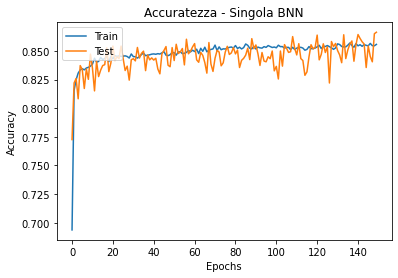

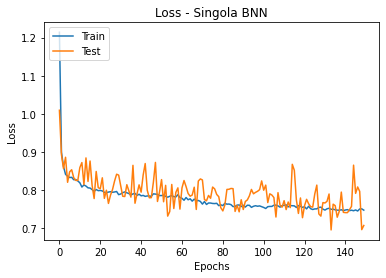

In [6]:
import matplotlib.pyplot as plt

# Plot curva accuratezza
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuratezza - Singola BNN')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot della curva loss 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss - Singola BNN')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

1/1 [==============================] - 0s 28ms/step


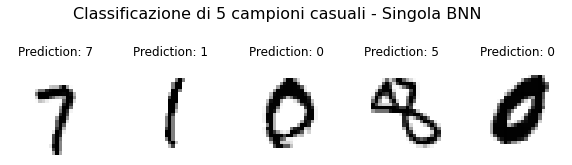

In [16]:
import numpy as np
import random

# Risultati della classificazione di 4 campioni casuali
sampled_imgs_index = random.sample(range(1, len(test_images)), 5)
sampled_imgs = []

for sample in sampled_imgs_index:
  sampled_imgs.append(train_images[sample])

predicted_imgs = model.predict(np.array(sampled_imgs))

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
fig.suptitle("Classificazione di 5 campioni casuali - Singola BNN", fontsize=16)
for ax, image, prediction in zip(axes, sampled_imgs, predicted_imgs):
  ax.set_axis_off()
  image = image.reshape(28, 28)
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title(f"Prediction: {np.argmax(prediction)}")

313/313 [==============================] - 1s 2ms/step


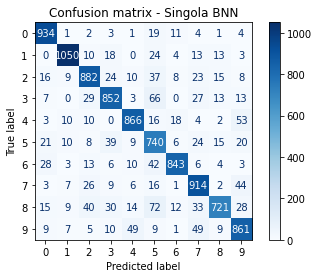

In [8]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Classificazione delle immagini e conversione label
predicted_images = model.predict(test_images)
predicted_labels = np.argmax(predicted_images, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm)

cm_fig.plot(cmap=plt.cm.Blues)
cm_fig.ax_.set_title("Confusion matrix - Singola BNN")
plt.show()

In [9]:
# Salvataggio dei pesi binarizzati e non binarizzati
model.save("full_precision_model.h5")  
fp_weights = model.get_weights()  

with lq.context.quantized_scope(True):
  model.save("binary_model.h5")  
  weights = model.get_weights()  

In [10]:
# Struttura della rete e statistiche 
lq.models.summary(model)

+sequential stats----------------------------------------------------------------------+
| Layer                  Input prec.    Outputs  # 1-bit  # 32-bit  Memory  1-bit MACs |
|                              (bit)                 x 1       x 1    (kB)             |
+--------------------------------------------------------------------------------------+
| flatten                          -  (-1, 784)        0         0       0           0 |
| quant_dense                      1   (-1, 32)    25088        32    3.19       25088 |
| batch_normalization              -   (-1, 32)        0        64    0.25           0 |
| quant_dense_1                    1   (-1, 16)      512        16    0.12         512 |
| batch_normalization_1            -   (-1, 16)        0        32    0.12           0 |
| quant_dense_2                    1   (-1, 10)      160        10    0.06         160 |
| batch_normalization_2            -   (-1, 10)        0        20    0.08           0 |
| activation         

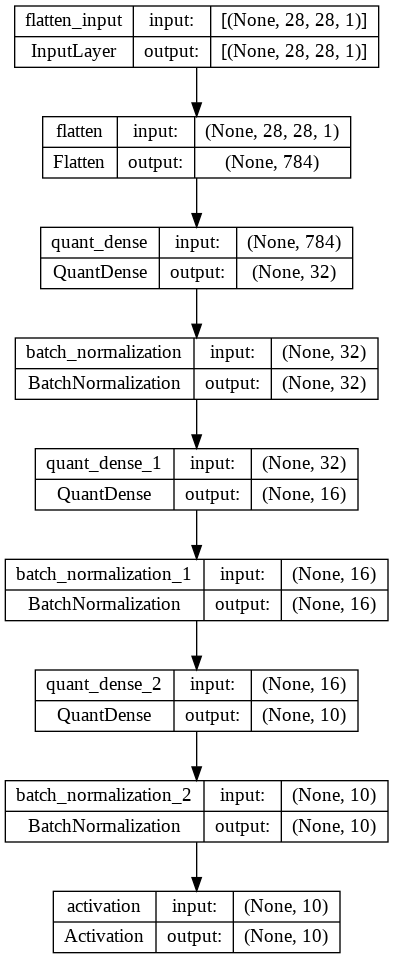

In [11]:
# Modello rete binarizzata
tf.keras.utils.plot_model(model, "single_bnn.png", show_shapes=True)

# 2. Analisi singole Deep Neural Network (DNN e BNN)
A seguire e' riportato il codice per l'implementazione di una Rete Neurale non binarizzata e di una Rete Neurale Binarizzata con piu' paramentri della precedente. 

In [23]:
# Architettura rete non binarizzata
model_dnn = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation="relu"),
    #tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

# Architettura rete binarizzata
model_bnn = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    lq.layers.QuantDense(64, **kwargs, input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(64, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    #lq.layers.QuantDense(32, **kwargs),
    #tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(10, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    tf.keras.layers.Activation("softmax")
])

# Configurazione algoritmo di ottimizzazione, funzione di costo e metrica
model_dnn.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics="accuracy")

model_bnn.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics="accuracy")

# Fitting della rete binarizzata e non binarizzata
history_dnn = model_dnn.fit(train_images, train_labels, batch_size=128, 
                            epochs=150, validation_data=(test_images, test_labels))

print(f"DNN Training: OK!\n")

history_bnn = model_bnn.fit(train_images, train_labels, batch_size=128, 
                            epochs=150, validation_data=(test_images, test_labels))

print(f"BNN Training: OK!\n")

# Validazione dei modelli con le immagini del test set
test_loss_dnn, test_acc_dnn = model_dnn.evaluate(test_images, test_labels)
test_loss_bnn, test_acc_bnn = model_bnn.evaluate(test_images, test_labels)
print(f"DNN - Test accuracy {test_acc_dnn * 100:.2f} %\n")
print(f"BNN - Test accuracy {test_acc_bnn * 100:.2f} %\n")

Epoch 1/150
469/469 [==============================] - 2s 4ms/step - loss: 0.5444 - accuracy: 0.8387 - val_loss: 0.2981 - val_accuracy: 0.9096
Epoch 2/150
469/469 [==============================] - 2s 3ms/step - loss: 0.2755 - accuracy: 0.9164 - val_loss: 0.2380 - val_accuracy: 0.9287
Epoch 3/150
469/469 [==============================] - 2s 4ms/step - loss: 0.2265 - accuracy: 0.9317 - val_loss: 0.2061 - val_accuracy: 0.9358
Epoch 4/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1933 - accuracy: 0.9422 - val_loss: 0.1764 - val_accuracy: 0.9466
Epoch 5/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1693 - accuracy: 0.9488 - val_loss: 0.1651 - val_accuracy: 0.9489
Epoch 6/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1532 - accuracy: 0.9527 - val_loss: 0.1453 - val_accuracy: 0.9565
Epoch 7/150
469/469 [==============================] - 2s 4ms/step - loss: 0.1405 - accuracy: 0.9575 - val_loss: 0.1384 - val_accuracy: 0.9572

In [26]:
# Salvataggio dei modelli 
model_dnn.save("large_dnn")
model_bnn.save("full_precision_large_bnn.h5")  
fp_weights = model_bnn.get_weights()  

with lq.context.quantized_scope(True):
  model_bnn.save("binary_large_bnn.h5")  
  weights = model_bnn.get_weights()  

Text(0.5, 1.0, 'BNN')

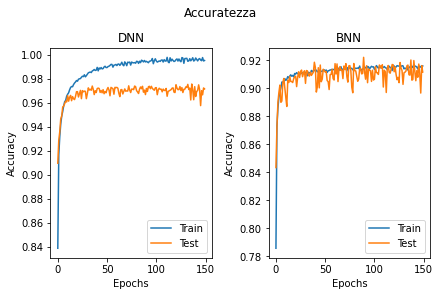

In [27]:
# Confronto accuratezza delle due reti 
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True)

fig.suptitle("Accuratezza")

# Plot curva accuratezza
ax1.plot(history_dnn.history['accuracy'])
ax1.plot(history_dnn.history['val_accuracy'])
ax1.set(xlabel="Epochs", ylabel="Accuracy")
ax1.legend(['Train', 'Test'], loc='best')
ax1.set_title("DNN")

ax2.plot(history_bnn.history['accuracy'])
ax2.plot(history_bnn.history['val_accuracy'])
ax2.set(xlabel="Epochs", ylabel="Accuracy")
ax2.legend(['Train', 'Test'], loc='best')
ax2.set_title("BNN")

Text(0.5, 1.0, 'BNN')

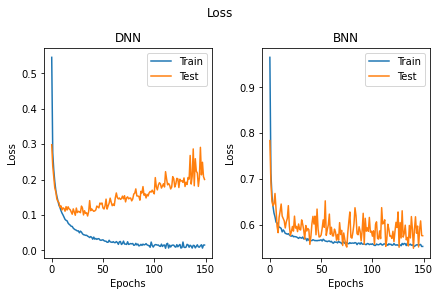

In [28]:
# Confronto loss delle due reti
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True)

fig.suptitle("Loss")

# Plot curva accuratezza
ax1.plot(history_dnn.history['loss'])
ax1.plot(history_dnn.history['val_loss'])
ax1.set(xlabel="Epochs", ylabel="Loss")
ax1.legend(['Train', 'Test'], loc='best')
ax1.set_title("DNN")

ax2.plot(history_bnn.history['loss'])
ax2.plot(history_bnn.history['val_loss'])
ax2.set(xlabel="Epochs", ylabel="Loss")
ax2.legend(['Train', 'Test'], loc='best')
ax2.set_title("BNN")

313/313 [==============================] - 1s 1ms/step


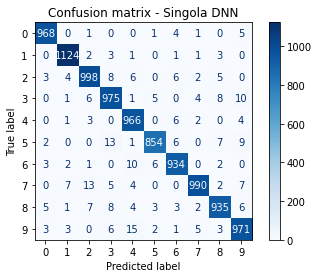

In [29]:
# Confusion matrix DNN
predicted_images_dnn = model_dnn.predict(test_images)
predicted_labels_dnn = np.argmax(predicted_images_dnn, axis=1)

cm_dnn = confusion_matrix(test_labels, predicted_labels_dnn)
cm_fig_dnn = ConfusionMatrixDisplay(confusion_matrix=cm_dnn)

cm_fig_dnn.plot(cmap=plt.cm.Blues)
cm_fig_dnn.ax_.set_title("Confusion matrix - Singola DNN")
plt.show()

313/313 [==============================] - 1s 2ms/step


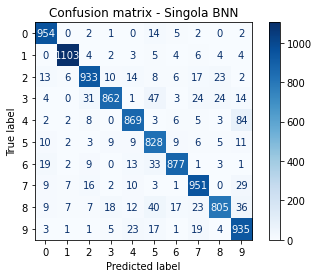

In [30]:
predicted_images_bnn = model_bnn.predict(test_images)
predicted_labels_bnn = np.argmax(predicted_images_bnn, axis=1)

cm_bnn = confusion_matrix(test_labels, predicted_labels_bnn)
cm_fig_bnn = ConfusionMatrixDisplay(confusion_matrix=cm_bnn)

cm_fig_bnn.plot(cmap=plt.cm.Blues)
cm_fig_bnn.ax_.set_title("Confusion matrix - Singola BNN")
plt.show()

# 3. Ensemble di Binarized Neural Networks
